# Training ORIGAMI with Continuous Numeric Values

This notebook demonstrates how to train an ORIGAMI model using continuous numeric values with the `NumericScaler` preprocessing and how to make predictions using the trained model.

The continuous head uses a Mixture of Gaussians (MoG) output to model numeric values, allowing the model to learn rich distributions over continuous fields rather than discretizing them into bins.

## 1. Create 2D Gaussian Dataset

We create a synthetic dataset with two correlated numeric fields `a` and `b` following a 2D Gaussian distribution.

In [1]:
import random
from copy import deepcopy

import numpy as np
import torch

# For reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

NUM_DOCS = 10000

# Create 2D Gaussian data with correlation
mean = [4, -2]
cov = [[1.0, 0.7], [0.7, 0.5]]  # Correlated covariance matrix

samples = np.random.multivariate_normal(mean, cov, NUM_DOCS)
docs = [{"a": float(x), "b": float(y)} for x, y in samples]

print(f"Created {len(docs)} documents")
print(f"Sample docs: {docs[:3]}")

Created 10000 documents
Sample docs: [{'a': 3.5103557462352297, 'b': -2.3589035228017097}, {'a': 3.281236621343086, 'b': -2.3540538636051225}, {'a': 4.244930169168411, 'b': -1.8508327613463913}]


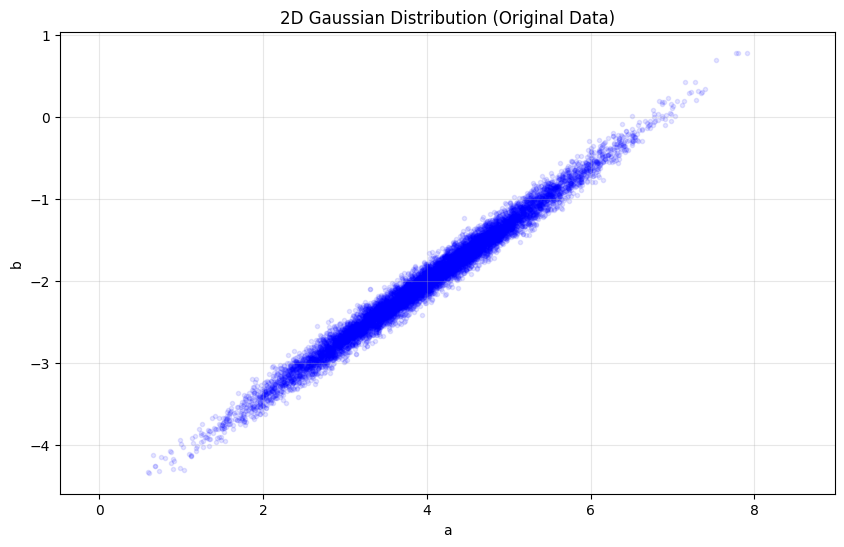

In [2]:
# Plot the data in a 2D scatter plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
plt.scatter([d["a"] for d in docs], [d["b"] for d in docs], marker=".", alpha=0.1, color="blue")
plt.title("2D Gaussian Distribution (Original Data)")
plt.xlabel("a")
plt.ylabel("b")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.show()

## 2. Preprocess Data with NumericScaler

The `NumericScaler` identifies high-cardinality numeric fields (more than `cat_threshold` unique values) and normalizes them using StandardScaler. The scaled values are wrapped in `ScaledNumeric` markers that the tokenizer converts to `NUM` tokens.

In [3]:
from origami.preprocessing import NumericScaler

# Create scaler - cat_threshold=20 ensures our continuous fields are scaled
# (they have many more than 20 unique values)
scaler = NumericScaler(cat_threshold=20)

# Fit and transform
scaled_docs = scaler.fit_transform(docs)

print("Scaler summary:")
print(scaler.summary())
print(f"\nSample scaled doc: {scaled_docs[0]}")

Scaler summary:
NumericScaler (cat_threshold=20)
  Scaled fields (2):
    a: mean=3.996, std=1.011
    b: mean=-2.002, std=0.7151
  Pass-through fields (0):

Sample scaled doc: {'a': ScaledNumeric(-0.4804), 'b': ScaledNumeric(-0.4991)}


## 3. Tokenize Data

The `JSONTokenizer` recognizes `ScaledNumeric` markers and emits `NUM` tokens with the associated scaled values stored separately.

In [4]:
from origami.tokenizer import JSONTokenizer

# Create and fit tokenizer
tokenizer = JSONTokenizer()
tokenizer.fit(scaled_docs)

print(f"Vocabulary size: {tokenizer.vocab.size}")
print(f"Max depth: {tokenizer.max_depth}")

# Tokenize a sample document
sample_instance = tokenizer.tokenize(scaled_docs[0])
print(f"\nSample tokenized instance:")
print(f"  Tokens: {sample_instance.tokens}")
print(f"  Numeric values: {sample_instance.numeric_values}")

Vocabulary size: 12
Max depth: 32

Sample tokenized instance:
  Tokens: [GrammarToken('START'), GrammarToken('OBJ_START'), KeyToken('a'), GrammarToken('NUM'), KeyToken('b'), GrammarToken('NUM'), GrammarToken('OBJ_END'), GrammarToken('END')]
  Numeric values: [None, None, None, -0.48041728652270543, None, -0.4990849987408165, None, None]


## 4. Create Model with Continuous Head

We create an ORIGAMI model with `use_continuous_head=True` to enable the Mixture of Gaussians output head for numeric values.

In [5]:
from origami.model import OrigamiConfig, OrigamiModel

# Model config with continuous head enabled
config = OrigamiConfig(
    vocab_size=tokenizer.vocab.size,
    d_model=64,
    n_heads=4,
    n_layers=4,
    d_ff=256,
    dropout=0.0,
    max_depth=tokenizer.max_depth,
    use_grammar_constraints=True,
    # Continuous head settings
    use_continuous_head=True,
    num_mixture_components=5,
    continuous_loss_weight=-1.0,  # Auto-calculate from NUM token proportion
)

model = OrigamiModel(config, vocab=tokenizer.vocab)

print(f"Model parameters: {model.get_num_parameters():,}")
print(f"Continuous head enabled: {model.continuous_head is not None}")
print(f"Mixture components: {config.num_mixture_components}")

Model parameters: 219,035
Continuous head enabled: True
Mixture components: 5


## 5. Train the Model

We use `OrigamiTrainer` to train the model. The trainer automatically handles the continuous loss when numeric values are present in the batch.

In [6]:
from origami.model import TrainingConfig
from origami.training import OrigamiTrainer

# Split data
train_size = int(0.9 * len(scaled_docs))
train_docs = scaled_docs[:train_size]
eval_docs = scaled_docs[train_size:]

print(f"Train size: {len(train_docs)}")
print(f"Eval size: {len(eval_docs)}")

# Training config
train_config = TrainingConfig(
    batch_size=64,
    num_epochs=20,
    learning_rate=1e-3,
    upscale_factor=1,  # No upscaling for this simple dataset
    warmup_steps=100,
    save_every_n_epochs=5,
)

# Create trainer
trainer = OrigamiTrainer(
    model=model,
    tokenizer=tokenizer,
    train_data=train_docs,
    eval_data=eval_docs,
    config=train_config,
    shuffle=False,  # Key order doesn't matter for this simple dataset
)

Train size: 9000
Eval size: 1000


In [7]:
# Train!
state = trainer.train()

Training on mps
Train samples: 9000 (base: 9000, upscale: 1x)
Eval samples: 1000
Batch size: 64
Epochs: 20
Total steps: 2800



Epoch 1/20 - Loss: 0.5841 - Tokens/sec: 20649


Epoch 2/20 - Loss: 0.2049 - Tokens/sec: 22524


Epoch 3/20 - Loss: 0.1704 - Tokens/sec: 22464


Epoch 4/20 - Loss: 0.1799 - Tokens/sec: 22372


...

Epoch 16/20 - Loss: 0.1289 - Tokens/sec: 21997


Epoch 17/20 - Loss: 0.1271 - Tokens/sec: 22074


Epoch 18/20 - Loss: 0.1266 - Tokens/sec: 22076


Epoch 19/20 - Loss: 0.1257 - Tokens/sec: 22013


Epoch 20/20 - Loss: 0.1248 - Tokens/sec: 21461
  Eval Loss: 0.1233


## 6. Generate Samples from the Model

We use `OrigamiGenerator` to sample complete JSON objects from the model. When the model generates a `NUM` token, it samples from the learned Mixture of Gaussians distribution.

In [8]:
from origami.inference import OrigamiGenerator

# Create generator
generator = OrigamiGenerator(model, tokenizer)

# Generate samples
n_samples = 1000
generated_samples = generator.generate(num_samples=n_samples, seed=SEED)

print(f"Generated {len(generated_samples)} samples")
print(f"Sample generated docs: {generated_samples[:3]}")

Generated 1000 samples
Sample generated docs: [{'a': 1.1539522409439087, 'b': 1.0844388008117676}, {'a': -0.13982334733009338, 'b': 0.04437504708766937}, {'a': -0.02864231914281845, 'b': -0.18346856534481049}]


In [9]:
# Inverse transform the sampled values back to original scale
generated_a = []
generated_b = []

for sample in generated_samples:
    if "a" in sample and "b" in sample:
        # The generator returns scaled values directly, we need to inverse transform
        a_scaled = sample["a"]
        b_scaled = sample["b"]

        # Inverse transform to original scale
        a_orig = scaler.inverse_transform_value("a", a_scaled)
        b_orig = scaler.inverse_transform_value("b", b_scaled)

        generated_a.append(a_orig)
        generated_b.append(b_orig)

print(f"Successfully inverse transformed {len(generated_a)} samples")

Successfully inverse transformed 1000 samples


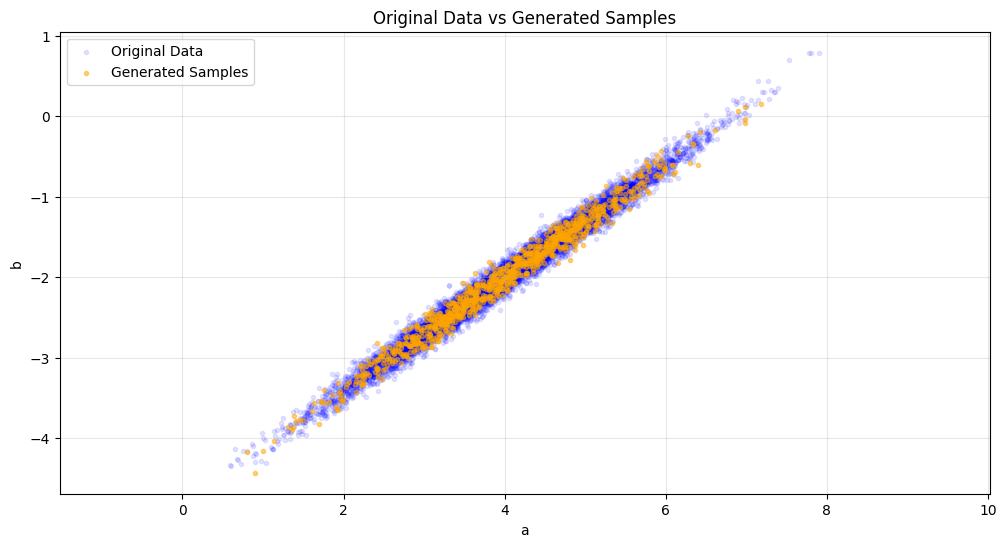

In [10]:
# Plot original data vs generated samples
fig, ax = plt.subplots(figsize=(12, 6))

# Original data
plt.scatter([d["a"] for d in docs], [d["b"] for d in docs], marker=".", alpha=0.1, color="blue", label="Original Data")

# Generated samples
plt.scatter(generated_a, generated_b, marker=".", alpha=0.5, color="orange", label="Generated Samples")

plt.title("Original Data vs Generated Samples")
plt.xlabel("a")
plt.ylabel("b")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Visualize the Learned Distribution

Let's look at the marginal distributions learned by the model for fields `a` and `b`.

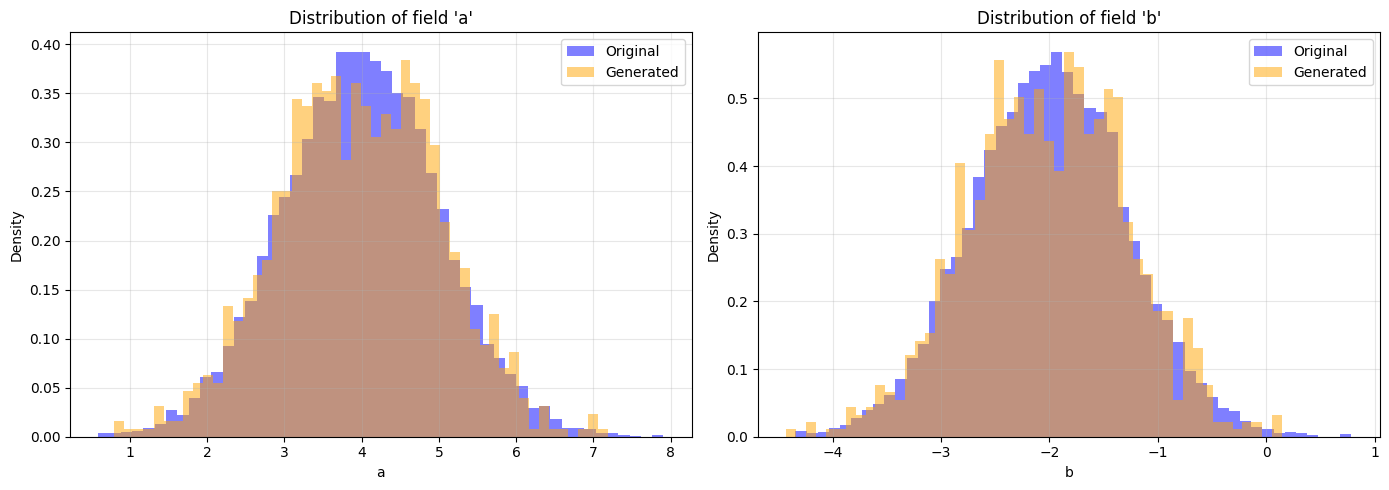

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Field 'a' distribution
axes[0].hist([d["a"] for d in docs], bins=50, alpha=0.5, density=True, label="Original", color="blue")
axes[0].hist(generated_a, bins=50, alpha=0.5, density=True, label="Generated", color="orange")
axes[0].set_title("Distribution of field 'a'")
axes[0].set_xlabel("a")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Field 'b' distribution
axes[1].hist([d["b"] for d in docs], bins=50, alpha=0.5, density=True, label="Original", color="blue")
axes[1].hist(generated_b, bins=50, alpha=0.5, density=True, label="Generated", color="orange")
axes[1].set_title("Distribution of field 'b'")
axes[1].set_xlabel("b")
axes[1].set_ylabel("Density")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Predict 'b' from 'a' using Conditional Generation

We can use the model to predict the value of `b` given a value for `a`. This tests whether the model has learned the correlation between the two fields.

In [12]:
from origami.preprocessing import move_target_last

# Create test data: sample every 100th point for visualization
test_indices = list(range(0, len(docs), 100))
test_docs = [docs[i] for i in test_indices]

print(f"Test set size: {len(test_docs)}")

# Scale test docs
test_scaled = scaler.transform(test_docs)

Test set size: 100


In [ ]:
# Generate predictions for 'b' given 'a' using the model's continuous head
# We'll do a forward pass and sample from the MoG at the position predicting 'b'

from origami.training import OrigamiDataCollator
from origami.tokenizer.vocabulary import KeyToken

predicted_b = []
true_a = [d["a"] for d in test_docs]
true_b = [d["b"] for d in test_docs]

collator = OrigamiDataCollator(tokenizer)
model.eval()

# Get the token ID for key "b"
b_key_id = tokenizer.vocab.encode(KeyToken("b"))

for doc in test_scaled:
    # Reorder so 'b' (target) is last
    reordered = move_target_last(doc, "b")
    
    # Tokenize and encode
    instance = tokenizer.tokenize(reordered)
    batch = collator([instance])
    
    # Forward pass - IMPORTANT: pass numeric_values so the model sees 'a's actual value!
    # Without this, all NUM tokens get the same generic embedding and the model
    # can't condition on a's value, resulting in predicting the unconditional mean.
    with torch.no_grad():
        output = model(
            batch["input_ids"],
            batch["path_types"],
            batch["path_ids"],
            batch["path_lengths"],
            batch["attention_mask"],
            numeric_values=batch["numeric_values"],  # Critical for conditioning!
        )
    
    # Find position of key "b" in the sequence
    b_pos = (batch["input_ids"][0] == b_key_id).nonzero(as_tuple=True)[0]
    if len(b_pos) > 0:
        # The logits at key "b" position predict the value after it
        # Get continuous params at that position
        weights, means, log_vars = output.continuous_params
        pos = b_pos[-1].item()  # Use last occurrence
        
        # Sample from MoG at this position
        w = weights[0, pos:pos+1, :]  # (1, n_components)
        m = means[0, pos:pos+1, :]
        lv = log_vars[0, pos:pos+1, :]
        
        sampled = model.continuous_head.sample(w.unsqueeze(0), m.unsqueeze(0), lv.unsqueeze(0))
        b_scaled = sampled[0, 0].item()
        
        # Inverse transform to original scale
        b_pred = scaler.inverse_transform_value("b", b_scaled)
        predicted_b.append(b_pred)
    else:
        # Fallback to mean if key not found
        predicted_b.append(mean[1])

print(f"Predicted {len(predicted_b)} values")
print(f"Sample predictions: {predicted_b[:5]}")

In [14]:
# Calculate metrics
mse = np.mean([(pred - true) ** 2 for pred, true in zip(predicted_b, true_b)])
mae = np.mean([abs(pred - true) for pred, true in zip(predicted_b, true_b)])
rmse = np.sqrt(mse)

# Baseline: predict mean
baseline_mse = np.mean([(mean[1] - true) ** 2 for true in true_b])
baseline_rmse = np.sqrt(baseline_mse)

print("\nPrediction Metrics:")
print(f"  MSE:  {mse:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE:  {mae:.4f}")
print(f"\nBaseline (predict mean):")
print(f"  MSE:  {baseline_mse:.4f}")
print(f"  RMSE: {baseline_rmse:.4f}")


Prediction Metrics:
  MSE:  0.5281
  RMSE: 0.7267
  MAE:  0.5577

Baseline (predict mean):
  MSE:  0.5002
  RMSE: 0.7073


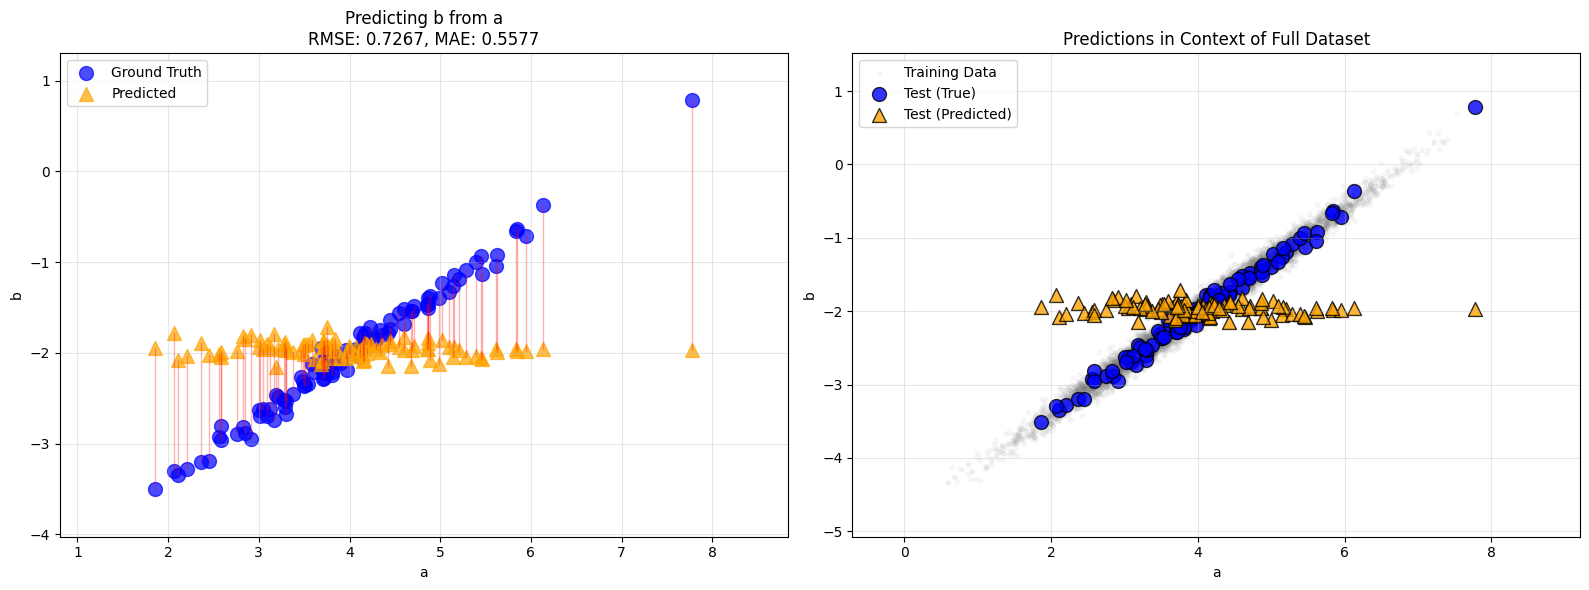

In [15]:
# Visualize predictions vs ground truth
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Predictions vs Ground Truth scatter
axes[0].scatter(true_a, true_b, alpha=0.7, s=100, label="Ground Truth", color="blue")
axes[0].scatter(true_a, predicted_b, alpha=0.7, s=100, label="Predicted", color="orange", marker="^")

# Draw lines connecting true to predicted for each point
for ta, tb, pb in zip(true_a, true_b, predicted_b):
    axes[0].plot([ta, ta], [tb, pb], "r-", alpha=0.3, linewidth=1)

axes[0].set_xlabel("a")
axes[0].set_ylabel("b")
axes[0].set_title(f"Predicting b from a\nRMSE: {rmse:.4f}, MAE: {mae:.4f}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axis("equal")

# Right plot: Show predictions overlaid on training data
axes[1].scatter(
    [d["a"] for d in docs], [d["b"] for d in docs], marker=".", alpha=0.05, color="gray", label="Training Data"
)
axes[1].scatter(true_a, true_b, alpha=0.8, s=100, label="Test (True)", color="blue", edgecolors="black", linewidths=1)
axes[1].scatter(
    true_a,
    predicted_b,
    alpha=0.8,
    s=100,
    label="Test (Predicted)",
    color="orange",
    marker="^",
    edgecolors="black",
    linewidths=1,
)

axes[1].set_xlabel("a")
axes[1].set_ylabel("b")
axes[1].set_title("Predictions in Context of Full Dataset")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axis("equal")

plt.tight_layout()
plt.show()

In [16]:
# Show example predictions
print("\nExample Predictions:")
print("=" * 60)
print(f"{'a value':<12} {'True b':<12} {'Predicted b':<12} {'Error':<12}")
print("=" * 60)
for i in range(min(15, len(test_docs))):
    error = predicted_b[i] - true_b[i]
    print(f"{true_a[i]:<12.3f} {true_b[i]:<12.3f} {predicted_b[i]:<12.3f} {error:<+12.3f}")


Example Predictions:
a value      True b       Predicted b  Error       
3.510        -2.359       -1.906       +0.453      
3.616        -2.214       -2.067       +0.147      
5.621        -0.918       -1.996       -1.078      
3.287        -2.595       -1.878       +0.716      
3.087        -2.695       -1.899       +0.796      
2.559        -2.923       -2.013       +0.910      
3.895        -2.117       -2.061       +0.056      
5.020        -1.227       -1.861       -0.634      
4.118        -1.779       -1.982       -0.203      
2.104        -3.342       -2.084       +1.258      
4.681        -1.534       -2.143       -0.609      
2.207        -3.283       -2.035       +1.248      
4.713        -1.480       -1.925       -0.445      
5.845        -0.638       -1.977       -1.340      
3.689        -1.949       -2.118       -0.168      


## 9. Inspect Learned Mixture Components

Let's visualize what the model has learned by looking at the mixture components it predicts for a specific input.

In [ ]:
# Take a sample document and look at the continuous head output
sample_doc = test_scaled[0]
reordered = move_target_last(sample_doc, "b")

# Tokenize and encode
instance = tokenizer.tokenize(reordered)
batch = collator([instance])

# Forward pass - pass numeric_values to encode a's actual value
model.eval()
with torch.no_grad():
    output = model(
        batch["input_ids"],
        batch["path_types"],
        batch["path_ids"],
        batch["path_lengths"],
        batch["attention_mask"],
        numeric_values=batch["numeric_values"],  # Critical for conditioning!
    )

# Get continuous params at the position where we predict 'b'
# This is the position of the 'b' key token
weights, means, log_vars = output.continuous_params

# Find position of key "b" - the logits at this position predict the value
b_pos = (batch["input_ids"][0] == b_key_id).nonzero(as_tuple=True)[0][-1].item()

print(f"Sequence length: {batch['attention_mask'][0].sum().item()}")
print(f"Key 'b' position: {b_pos}")
print(f"\nMixture parameters at position predicting 'b' value:")
print(f"  Weights: {weights[0, b_pos].numpy()}")
print(f"  Means (scaled): {means[0, b_pos].numpy()}")
print(f"  Stds (scaled): {torch.exp(0.5 * log_vars[0, b_pos]).numpy()}")

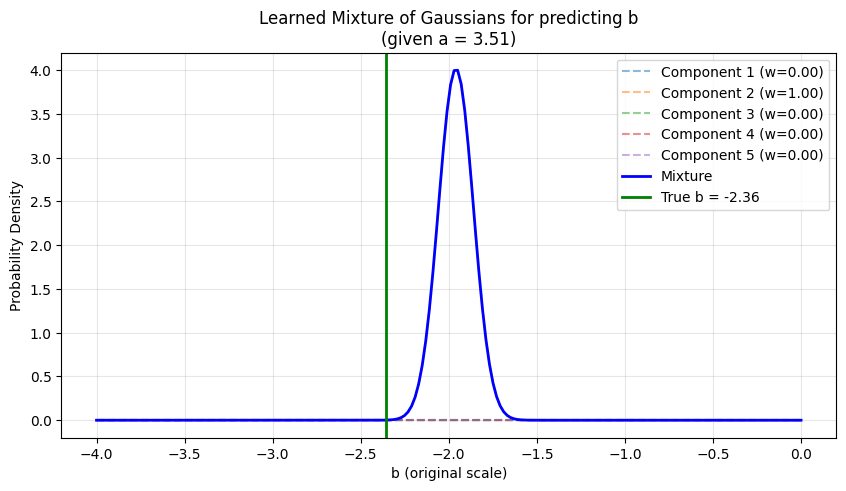

In [18]:
# Visualize the mixture distribution
w = weights[0, b_pos].numpy()
m = means[0, b_pos].numpy()
s = np.exp(0.5 * log_vars[0, b_pos].numpy())

# Inverse transform means to original scale for plotting
stats = scaler.get_scaler_stats("b")
m_orig = m * stats["std"] + stats["mean"]
s_orig = s * stats["std"]

x = np.linspace(-4, 0, 200)

# Plot mixture PDF
fig, ax = plt.subplots(figsize=(10, 5))

# Individual components
for i, (wi, mi, si) in enumerate(zip(w, m_orig, s_orig)):
    pdf = wi * np.exp(-0.5 * ((x - mi) / si) ** 2) / (si * np.sqrt(2 * np.pi))
    ax.plot(x, pdf, "--", alpha=0.5, label=f"Component {i + 1} (w={wi:.2f})")

# Mixture PDF
mixture_pdf = np.zeros_like(x)
for wi, mi, si in zip(w, m_orig, s_orig):
    mixture_pdf += wi * np.exp(-0.5 * ((x - mi) / si) ** 2) / (si * np.sqrt(2 * np.pi))
ax.plot(x, mixture_pdf, "b-", linewidth=2, label="Mixture")

# Mark true value
true_val = test_docs[0]["b"]
ax.axvline(true_val, color="green", linestyle="-", linewidth=2, label=f"True b = {true_val:.2f}")

ax.set_xlabel("b (original scale)")
ax.set_ylabel("Probability Density")
ax.set_title(f"Learned Mixture of Gaussians for predicting b\n(given a = {test_docs[0]['a']:.2f})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Summary

This notebook demonstrated:

1. **NumericScaler preprocessing**: Identifies high-cardinality numeric fields and normalizes them using StandardScaler, wrapping values in `ScaledNumeric` markers.

2. **Continuous head training**: The model learns a Mixture of Gaussians distribution for each NUM token position, enabling rich density estimation over continuous values.

3. **Unconditional generation**: The model can sample complete JSON documents from the learned distribution, capturing both marginal distributions and correlations.

4. **Conditional prediction**: Given some fields, the model can predict missing fields while respecting learned correlations.

The continuous head is particularly useful for:
- High-cardinality numeric fields that would require too many bins if discretized
- Preserving continuous relationships between fields
- Generating realistic numeric values from learned distributions